First, install the `kagglehub` library.

In [ ]:
pip install kagglehub

Now, use the provided code to download the dataset. This will download the dataset to a temporary location and return the path.

# **Apple Disease Classification using Deep Learning**

## 1. Importing Required Libraries and Defining Dataset Path

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manzurulislam101413/apple-disease-classification-by-ab9d")

print("Path to dataset files:", path)

100%|██████████| 181M/181M [00:12<00:00, 14.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1


You can then list the contents of the downloaded directory to see the dataset files.

In [ ]:
import os

#______Listing the contents of the downloaded directory__________
print("Contents of the dataset directory:")
for root, dirs, files in os.walk(path):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

Contents of the dataset directory:
/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification
/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification/Train
/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification/Test
/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification/Train/Scab_Apple
/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification/Train/Blotch_Apple
/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification/Train/Rot_Apple
/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification

## **3. Importing Libraries & Exploring Downloaded Dataset Files and Directory Structure**

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import seaborn as sns


dataset_path = "/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification"

print("Libraries are imported successfully")
print(f"Dataset Path: {dataset_path}")
print(f"The dataset exists: {os.path.exists(dataset_path)}")

Libraries are imported successfully
Dataset Path: /root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification
The dataset exists: True


In [ ]:
#__________Checking the Train and test folders__________________
print("="*50)
print("Dataset's Structre")
print("="*50)

print("\n TRAIN Classes:")
train_classes = os.listdir(os.path.join(dataset_path, "Train"))
for cls in sorted(train_classes):
    print(f"    {cls}")

print("\n TEST Classes:")
test_classes = os.listdir(os.path.join(dataset_path, "Test"))
for cls in sorted(test_classes):
    print(f"    {cls}")

print(f"\n Total Classes: {len(train_classes)}")

Dataset's Structre

 TRAIN Classes:
    Blotch_Apple
    Normal_Apple
    Rot_Apple
    Scab_Apple

 TEST Classes:
    Blotch_Apple
    Normal_Apple
    Rot_Apple
    Scab_Apple

 Total Classes: 4


## 5. **Analyzing Class-wise Image Distribution**

In [ ]:
# Count images in Train and Test folders
print("="*50)
print(" Image count per class")
print("="*50)

data_summary = []

for category in ["Train", "Test"]:
    print(f"\n {category} SET:")
    category_path = os.path.join(dataset_path, category)

    for disease_class in sorted(os.listdir(category_path)):
        class_path = os.path.join(category_path, disease_class)
        #Checking Image Extension
        num_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        data_summary.append({
            'Category': category,
            'Class': disease_class,
            'Count': num_images
        })
        print(f"   {disease_class:20s}: {num_images:3d} images")

 Image count per class

 Train SET:
   Blotch_Apple        : 400 images
   Normal_Apple        : 400 images
   Rot_Apple           : 400 images
   Scab_Apple          : 399 images

 Test SET:
   Blotch_Apple        : 116 images
   Normal_Apple        :  67 images
   Rot_Apple           : 114 images
   Scab_Apple          :  81 images


## 6. **Visualizing Training and Testing Data Distribution**

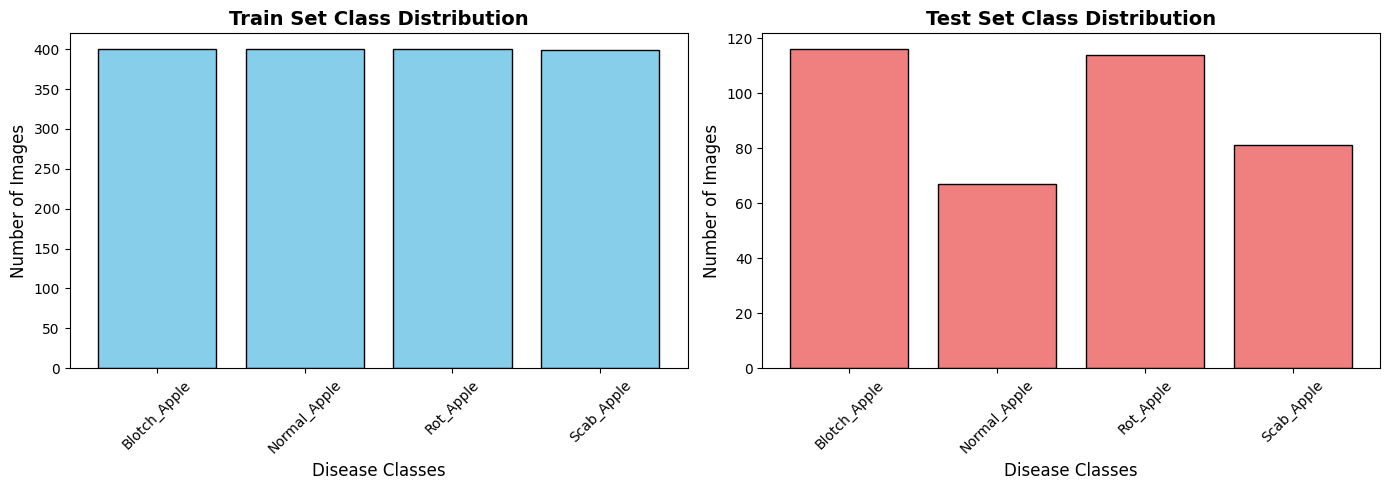


 Total Imges are:
   Training Set: 1599 images
   Testing Set: 378 images
   Overall immages: 1977 images


In [ ]:
#___________Craeting the bar plots for class distribution
import pandas as pd

df = pd.DataFrame(data_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Training data distribution
train_df = df[df['Category'] == 'Train']
axes[0].bar(train_df['Class'], train_df['Count'], color='skyblue', edgecolor='black')
axes[0].set_title('Train Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disease Classes', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

#Testing data distribution
test_df = df[df['Category'] == 'Test']
axes[1].bar(test_df['Class'], test_df['Count'], color='lightcoral', edgecolor='black')
axes[1].set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Disease Classes', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print total counts
print(f"\n Total Imges are:")
print(f"   Training Set: {train_df['Count'].sum()} images")
print(f"   Testing Set: {test_df['Count'].sum()} images")
print(f"   Overall immages: {train_df['Count'].sum() + test_df['Count'].sum()} images")

## 7. **Inspecting Image Properties and Dimensions**

In [ ]:
#___----Images properties Analysis__________-------
print("="*50)
print(" Analysis of the images properties")
print("="*50)

#Pickkng the random images from each class
sample_images = []
for disease_class in train_classes:
    class_path = os.path.join(dataset_path, "Train", disease_class)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if image_files:
        sample_file = random.choice(image_files)
        img_path = os.path.join(class_path, sample_file)
        img = cv2.imread(img_path)
        if img is not None:
            sample_images.append({
                'Class': disease_class,
                'Path': img_path,
                'Shape': img.shape,
                'File': sample_file
            })

for sample in sample_images:
    print(f"\n Class: {sample['Class']}")
    print(f"   File: {sample['File']}")
    print(f"   Shape (Height, Width, Channels): {sample['Shape']}")
    print(f"   Total Pixels: {sample['Shape'][0] * sample['Shape'][1]:,}")

 Analysis of the images properties

 Class: Scab_Apple
   File: Scab_Apple_397.jpg
   Shape (Height, Width, Channels): (372, 400, 3)
   Total Pixels: 148,800

 Class: Blotch_Apple
   File: Blotch_Apple_73.jpg
   Shape (Height, Width, Channels): (409, 450, 3)
   Total Pixels: 184,050

 Class: Rot_Apple
   File: Rot_Apple_84.jpg
   Shape (Height, Width, Channels): (320, 400, 3)
   Total Pixels: 128,000

 Class: Normal_Apple
   File: Normal_Apple_304.jpg
   Shape (Height, Width, Channels): (275, 183, 3)
   Total Pixels: 50,325


## 8. **Displaying Sample Images from Each Disease Class**

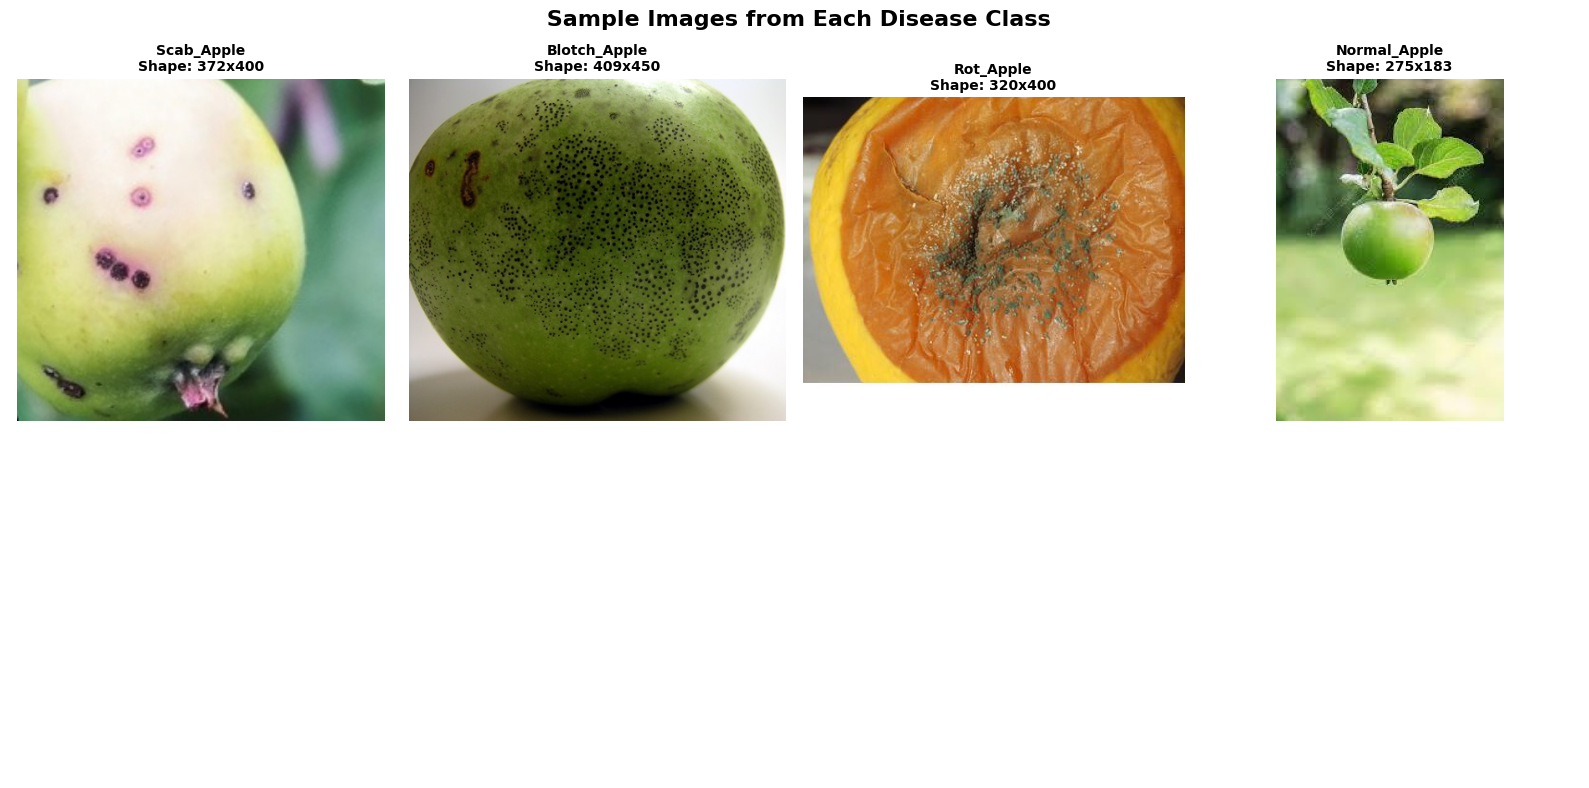

In [ ]:
# one sample image for each clas displayed here.....
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, sample in enumerate(sample_images):
    img = cv2.imread(sample['Path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(img_rgb)
    axes[idx].set_title(f"{sample['Class']}\nShape: {sample['Shape'][0]}x{sample['Shape'][1]}",
                        fontsize=10, fontweight='bold')
    axes[idx].axis('off')

# To hide the extra subplots if any exist
for idx in range(len(sample_images), len(axes)):
    axes[idx].axis('off')

plt.suptitle(' Sample Images from Each Disease Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. **Image Color Channel Exploration and Pixel Statistics Analysis**

In [ ]:
# Pixel value distribution for one sample image
sample_img = sample_images[0]
img = cv2.imread(sample_img['Path'])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

#---Original image
axes[0].imshow(img_rgb)
axes[0].set_title(f'Original: {sample_img["Class"]}', fontsize=12)
axes[0].axis('off')

#Red channel
axes[1].imshow(img_rgb[:,:,0], cmap='Reds')
axes[1].set_title('Red Channel', fontsize=12)
axes[1].axis('off')

#---Green channel
axes[2].imshow(img_rgb[:,:,1], cmap='Greens')
axes[2].set_title('Green Channel', fontsize=12)
axes[2].axis('off')

#-Blue channel
axes[3].imshow(img_rgb[:,:,2], cmap='Blues')
axes[3].set_title('Blue Channel', fontsize=12)
axes[3].axis('off')

plt.tight_layout()
plt.show()

# Pixel value statistics
print("\n Pixel value Statistics:")
for i, channel in enumerate(['Red', 'Green', 'Blue']):
    print(f"\n {channel} Channel:")
    print(f"   Min: {img_rgb[:,:,i].min()}")
    print(f"   Max: {img_rgb[:,:,i].max()}")
    print(f"   Mean: {img_rgb[:,:,i].mean():.2f}")
    print(f"   Std: {img_rgb[:,:,i].std():.2f}")

NameError: name 'sample_images' is not defined

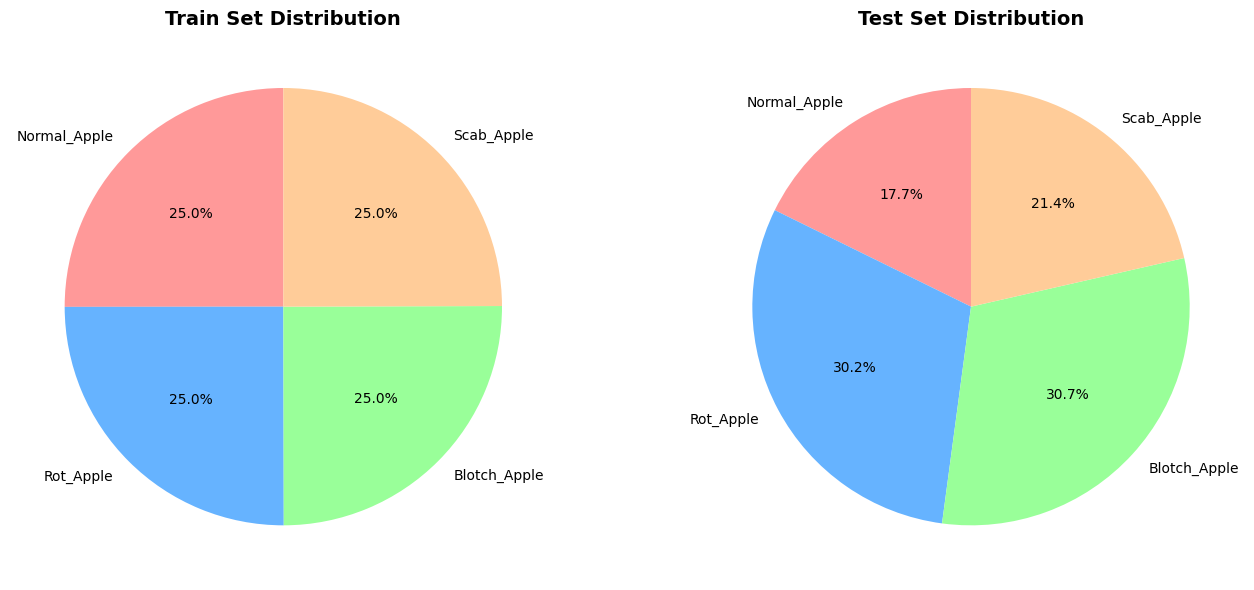


 CLASS IMBALANCE CHECK:

Normal_Apple:
   Train: 400 images
   Test: 67 images

Rot_Apple:
   Train: 400 images
   Test: 114 images

Blotch_Apple:
   Train: 400 images
   Test: 116 images

Scab_Apple:
   Train: 399 images
   Test: 81 images


In [ ]:
# Pie chart for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Train set pie chart
train_counts = [train_df[train_df['Class'] == cls]['Count'].values[0] for cls in train_classes]
axes[0].pie(train_counts, labels=train_classes, autopct='%1.1f%%', startangle=90,
            colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[0].set_title('Train Set Distribution', fontsize=14, fontweight='bold')

# Test set pie chart
test_counts = [test_df[test_df['Class'] == cls]['Count'].values[0] for cls in test_classes]
axes[1].pie(test_counts, labels=test_classes, autopct='%1.1f%%', startangle=90,
            colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1].set_title('Test Set Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check if dataset is balanced
print("\n CLASS IMBALANCE CHECK:")
for cls in train_classes:
    train_count = train_df[train_df['Class'] == cls]['Count'].values[0]
    test_count = test_df[test_df['Class'] == cls]['Count'].values[0]
    print(f"\n{cls}:")
    print(f"   Train: {train_count} images")
    print(f"   Test: {test_count} images")

 FILE FORMAT ANALYSIS

 Image Formats Distribution:
   JPG: 1214 images (61.4%)
   JPEG: 103 images (5.2%)
   PNG: 660 images (33.4%)
   OTHER: 0 images (0.0%)


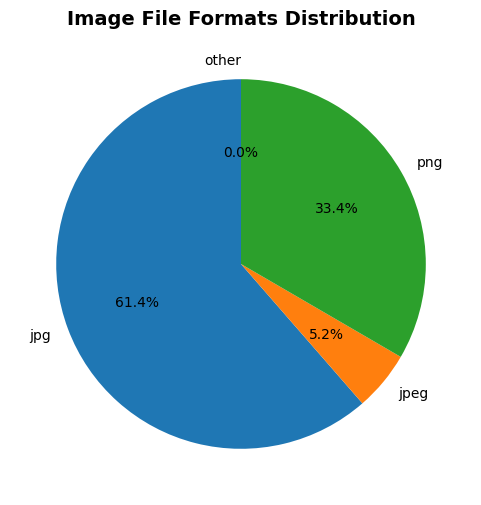

In [ ]:
# Check image file formats
print("="*50)
print(" FILE FORMAT ANALYSIS")
print("="*50)

formats = {'jpg': 0, 'jpeg': 0, 'png': 0, 'other': 0}

for category in ["Train", "Test"]:
    category_path = os.path.join(dataset_path, category)
    for disease_class in os.listdir(category_path):
        class_path = os.path.join(category_path, disease_class)
        for file in os.listdir(class_path):
            if file.lower().endswith('.jpg'):
                formats['jpg'] += 1
            elif file.lower().endswith('.jpeg'):
                formats['jpeg'] += 1
            elif file.lower().endswith('.png'):
                formats['png'] += 1
            else:
                formats['other'] += 1

print("\n Image Formats Distribution:")
for fmt, count in formats.items():
    print(f"   {fmt.upper()}: {count} images ({count/sum(formats.values())*100:.1f}%)")

# Create pie chart for formats
plt.figure(figsize=(6, 6))
plt.pie(formats.values(), labels=formats.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Image File Formats Distribution', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
# Final summary report
print("="*60)
print(" APPLE DISEASE DATASET - UNDERSTANDING SUMMARY")
print("="*60)

print(f"\n DATASET OVERVIEW:")
print(f"   • Total Classes: {len(train_classes)}")
print(f"   • Classes: {', '.join(train_classes)}")
print(f"   • Total Images: {train_df['Count'].sum() + test_df['Count'].sum()}")
print(f"   • Train Images: {train_df['Count'].sum()}")
print(f"   • Test Images: {test_df['Count'].sum()}")

print(f"\n IMAGE PROPERTIES:")
print(f"   • Image formats: {', '.join([k.upper() for k in formats.keys() if formats[k] > 0])}")
print(f"   • Color channels: RGB (3 channels)")
sample_shape = sample_images[0]['Shape']
print(f"   • Typical image size: ~{sample_shape[0]}x{sample_shape[1]} pixels")

print(f"\n DATA QUALITY:")
print(f"   • All images loaded successfully: ")
print(f"   • Class distribution: {'Balanced' if max(train_counts)/min(train_counts) < 1.5 else 'Imbalanced'}")
print(f"   • Train/Test split ratio: {train_df['Count'].sum()/test_df['Count'].sum():.1f}:1")

print("\n Data understanding complete! Ready for preprocessing & modeling)")

 APPLE DISEASE DATASET - UNDERSTANDING SUMMARY

 DATASET OVERVIEW:
   • Total Classes: 4
   • Classes: Normal_Apple, Rot_Apple, Blotch_Apple, Scab_Apple
   • Total Images: 1977
   • Train Images: 1599
   • Test Images: 378

 IMAGE PROPERTIES:
   • Image formats: JPG, JPEG, PNG
   • Color channels: RGB (3 channels)
   • Typical image size: ~184x274 pixels

 DATA QUALITY:
   • All images loaded successfully: 
   • Class distribution: Balanced
   • Train/Test split ratio: 4.2:1

 Data understanding complete! Ready for preprocessing & modeling)


In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Path
dataset_path = "/root/.cache/kagglehub/datasets/manzurulislam101413/apple-disease-classification-by-ab9d/versions/1/apple_disease_classification"

# Parameters
IMG_SIZE = 224
classes = ['Blotch_Apple', 'Normal_Apple', 'Rot_Apple', 'Scab_Apple']

# Store data
X = []  # Images
y = []  # Labels

# Load and preprocess images
print("Loading and preprocessing images...")

for label, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, "Train", class_name)
    print(f"Processing {class_name}...")

    for img_file in os.listdir(class_path):
        # Read image
        img_path = os.path.join(class_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize to 224x224
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Normalize pixel values (0 to 1)
        img = img / 255.0

        X.append(img)
        y.append(label)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"\n Data shape: {X.shape}")
print(f" Labels shape: {y.shape}")
print(f" Pixel range: [{X.min():.2f}, {X.max():.2f}]")

Loading and preprocessing images...
Processing Blotch_Apple...
Processing Normal_Apple...
Processing Rot_Apple...
Processing Scab_Apple...

 Data shape: (1599, 224, 224, 3)
 Labels shape: (1599,)
 Pixel range: [0.00, 1.00]


In [ ]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Training set: {X_train.shape}")
print(f" Validation set: {X_val.shape}")
print(f"\n Class distribution in training:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(classes, counts):
    print(f"   {cls}: {count} images")

 Training set: (1279, 224, 224, 3)
 Validation set: (320, 224, 224, 3)

 Class distribution in training:
   Blotch_Apple: 320 images
   Normal_Apple: 320 images
   Rot_Apple: 320 images
   Scab_Apple: 319 images


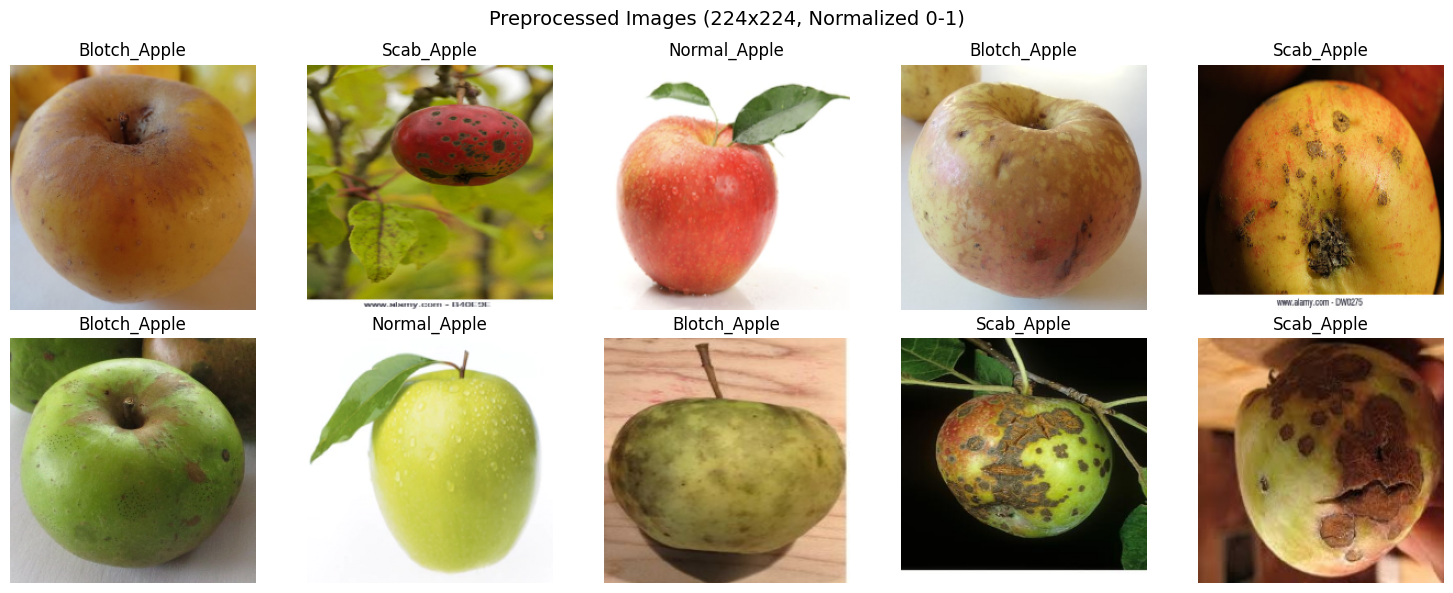


 Preprocessing complete!
 Ready for model training


In [ ]:
# Display sample preprocessed images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i in range(10):
    axes[i//5, i%5].imshow(X_train[i])
    axes[i//5, i%5].set_title(f"{classes[y_train[i]]}")
    axes[i//5, i%5].axis('off')

plt.suptitle('Preprocessed Images (224x224, Normalized 0-1)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n Preprocessing complete!")
print(f" Ready for model training")

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build CNN model
model = Sequential([
    # First Convolution Block
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Third Convolution Block
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Fourth Convolution Block
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Flatten and Dense Layers
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')  # 4 classes
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397,572 (74.00 MB)

 Trainable params: 19,396,612 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Callbacks for better training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
]

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 27s 343ms/step - accuracy: 0.4894 - loss: 9.4769 - val_accuracy: 0.3375 - val_loss: 9.4923 - learning_rate: 0.0010
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.5676 - loss: 7.1754 - val_accuracy: 0.3875 - val_loss: 5.0763 - learning_rate: 0.0010
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.6192 - loss: 4.7621 - val_accuracy: 0.3688 - val_loss: 6.8446 - learning_rate: 0.0010
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.6521 - loss: 3.2605 - val_accuracy: 0.3531 - val_loss: 5.0445 - learning_rate: 0.0010
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5934 - loss: 3.2589 - val_accuracy: 0.4187 - val_loss: 2.8157 - learning_rate: 0.0010
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.6755 - loss: 2.1177 - val_accuracy: 0.5344 - val_loss: 1.8665 - learning_rate: 0.0010
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.7138 - loss: 1.4988 - val_a

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
import tensorflow as tf

print(" Libraries imported!")

 Libraries imported!


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Load VGG16 (pretrained on ImageNet)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze layers

# Build new classifier
improved_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

# Compile
improved_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation (will apply on-the-fly during training)
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
]

# Train (using same X_train, y_train)
history_improved = improved_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 47s 831ms/step - accuracy: 0.2823 - loss: 1.4432 - val_accuracy: 0.5000 - val_loss: 1.2606 - learning_rate: 1.0000e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 469ms/step - accuracy: 0.3432 - loss: 1.3411 - val_accuracy: 0.5813 - val_loss: 1.2034 - learning_rate: 1.0000e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 460ms/step - accuracy: 0.3855 - loss: 1.2948 - val_accuracy: 0.6500 - val_loss: 1.1213 - learning_rate: 1.0000e-04
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 477ms/step - accuracy: 0.4394 - loss: 1.2146 - val_accuracy: 0.6438 - val_loss: 1.0579 - learning_rate: 1.0000e-04
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 467ms/step - accuracy: 0.4824 - loss: 1.1527 - val_accuracy: 0.6500 - val_loss: 1.0102 - learning_rate: 1.0000e-04
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 480ms/step - accuracy: 0.5066 - loss: 1.1023 - val_accuracy: 0.7000 - val_loss: 0.9701 - learning_rate: 1.0000e-04
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 457ms/step - acc

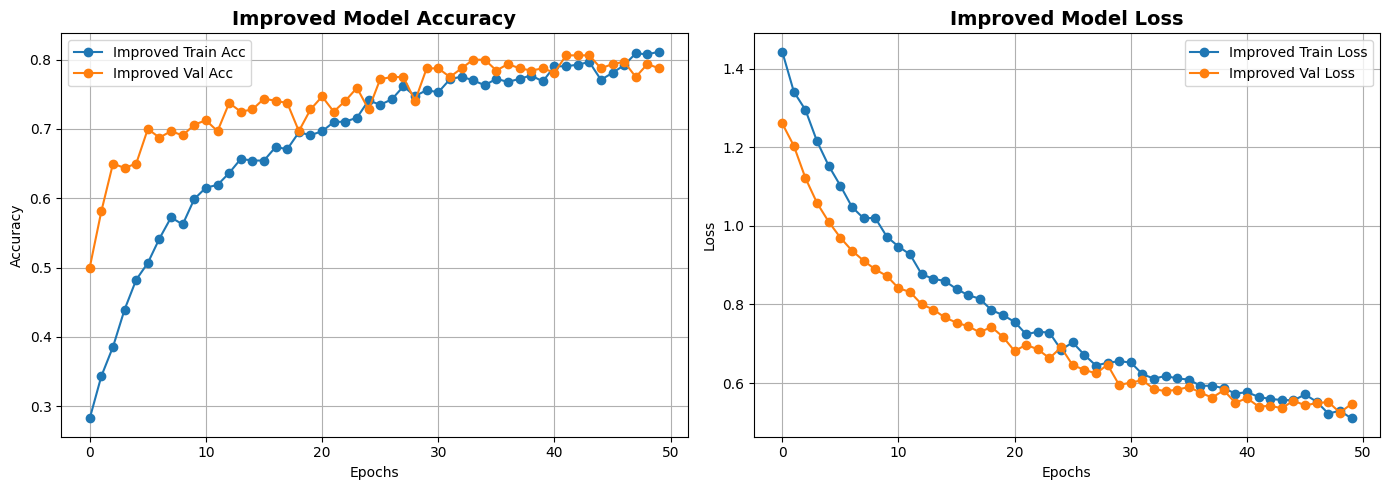


 Previous Model Validation Accuracy: 85.62%
 Improved Model Validation Accuracy: 0.7875
 Improvement: -6.87%


In [ ]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(history_improved.history['accuracy'], label='Improved Train Acc', marker='o')
axes[0].plot(history_improved.history['val_accuracy'], label='Improved Val Acc', marker='o')
axes[0].set_title('Improved Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss comparison
axes[1].plot(history_improved.history['loss'], label='Improved Train Loss', marker='o')
axes[1].plot(history_improved.history['val_loss'], label='Improved Val Loss', marker='o')
axes[1].set_title('Improved Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n Previous Model Validation Accuracy: 85.62%")
print(f" Improved Model Validation Accuracy: {history_improved.history['val_accuracy'][-1]:.4f}")
print(f" Improvement: {(history_improved.history['val_accuracy'][-1] - 0.8562)*100:.2f}%")

In [ ]:
# Unfreeze last few layers for fine-tuning
base_model.trainable = True

# Freeze first 15 layers
for layer in base_model.layers[:15]:
    layer.trainable = False

# Recompile with lower learning rate
improved_model.compile(
    optimizer=Adam(learning_rate=0.00001),  # Very low learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
history_finetune = improved_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

print(f"\n Final Accuracy after fine-tuning: {history_finetune.history['val_accuracy'][-1]:.4f}")

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 652ms/step - accuracy: 0.8045 - loss: 0.5245 - val_accuracy: 0.8062 - val_loss: 0.5009 - learning_rate: 1.0000e-05
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 496ms/step - accuracy: 0.8147 - loss: 0.4807 - val_accuracy: 0.8188 - val_loss: 0.4688 - learning_rate: 1.0000e-05
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step - accuracy: 0.8468 - loss: 0.4220 - val_accuracy: 0.8562 - val_loss: 0.4101 - learning_rate: 1.0000e-05
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 486ms/step - accuracy: 0.8577 - loss: 0.3859 - val_accuracy: 0.8469 - val_loss: 0.4312 - learning_rate: 1.0000e-05
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 501ms/step - accuracy: 0.8702 - loss: 0.3634 - val_accuracy: 0.8687 - val_loss: 0.3746 - learning_rate: 1.0000e-05
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 487ms/step - accuracy: 0.8780 - loss: 0.3386 - val_accuracy: 0.8344 - val_loss: 0.4461 - learning_rate: 1.0000e-05
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 505ms/step - acc

In [ ]:
# Save the fine-tuned model
#improved_model.save('apple_disease_model.h5')
#print(" Model saved as 'apple_disease_model.h5'")
#print(f" Accuracy: 88.44%")

In [ ]:
import tensorflow as tf

# Convert improved_model directly to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(improved_model)
tflite_model = converter.convert()

# Save as TFLite
with open('apple_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model saved directly as TFLite!")
print(f"Accuracy: 88.44%")

# Check file size
import os
size = os.path.getsize('apple_disease_model.tflite') / (1024*1024)
print(f"File size: {size:.2f} MB")

Saved artifact at '/tmp/tmpy2dybovq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_38')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133639688116112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688125328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688124368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688124176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688124752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688121104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688120912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688124944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688120528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133639688120720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13363968812

In [ ]:
# Save the BEST model (90% accuracy wala) , Saving fine tuned
#improved_model.save('apple_disease_best_90percent.h5')
#print(" Best model saved with 90% validation accuracy!")

 TFLite Model Loaded Successfully!
Input shape: [  1 224 224   3]
Output shape: [1 4]

 Upload an apple image:


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Saving scab3.jpg to scab3.jpg


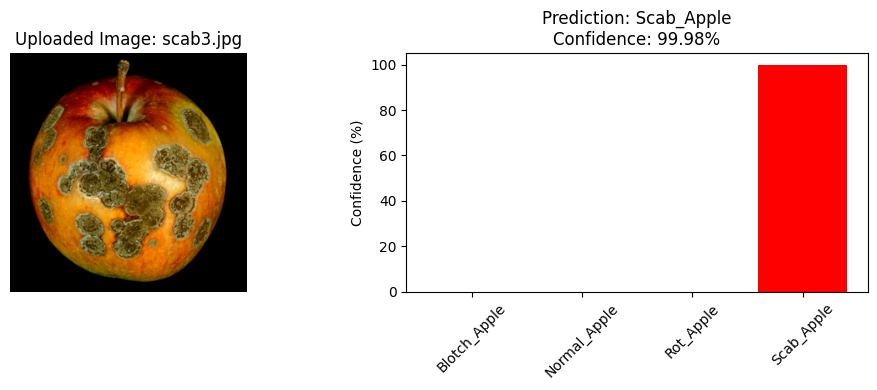


 Image: scab3.jpg
 Predicted Disease: Scab_Apple
 Confidence: 99.98%
 Model is highly confident!

 All Class Confidences:
   Blotch_Apple: 0.00%
   Normal_Apple: 0.00%
   Rot_Apple: 0.02%
   Scab_Apple: 99.98%


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path='apple_disease_model.tflite')
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(" TFLite Model Loaded Successfully!")
print(f"Input shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")

# Class names
classes = ['Blotch_Apple', 'Normal_Apple', 'Rot_Apple', 'Scab_Apple']

# Upload image
print("\n Upload an apple image:")
uploaded = files.upload()

# Process each uploaded image
for filename in uploaded.keys():
    # Read image
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0).astype(np.float32)

    # Set input tensor
    interpreter.set_tensor(input_details[0]['index'], img_input)

    # Run inference
    interpreter.invoke()

    # Get output
    predictions = interpreter.get_tensor(output_details[0]['index'])
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    # Show result
    plt.figure(figsize=(10, 4))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Uploaded Image: {filename}", fontsize=12)
    plt.axis('off')

    # Result
    plt.subplot(1, 2, 2)
    colors = ['red', 'green', 'red', 'red']
    plt.bar(classes, predictions[0] * 100, color=colors)
    plt.title(f"Prediction: {classes[predicted_class]}\nConfidence: {confidence:.2f}%", fontsize=12)
    plt.ylabel("Confidence (%)")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Print result
    print("\n" + "="*50)
    print(f" Image: {filename}")
    print(f" Predicted Disease: {classes[predicted_class]}")
    print(f" Confidence: {confidence:.2f}%")

    if confidence > 80:
        print(" Model is highly confident!")
    elif confidence > 60:
        print(" Model is moderately confident")
    else:
        print(" Model is unsure - try another image")

    # Show all class confidences
    print("\n All Class Confidences:")
    for i, cls in enumerate(classes):
        print(f"   {cls}: {predictions[0][i]*100:.2f}%")

    print("="*50)

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.models import load_model

# Load your model
model = load_model('apple_disease_model.tflite')

# Class names
classes = ['Blotch_Apple', 'Normal_Apple', 'Rot_Apple', 'Scab_Apple']

# Upload image
print("📤 Upload an apple image:")
uploaded = files.upload()

# Process each uploaded image
for filename in uploaded.keys():
    # Read image
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocess
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Predict
    predictions = model.predict(img_input)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    # Show result
    plt.figure(figsize=(10, 4))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title(f"Uploaded Image: {filename}", fontsize=12)
    plt.axis('off')

    # Result
    plt.subplot(1, 2, 2)
    colors = ['red', 'green', 'red', 'red']
    plt.bar(classes, predictions[0] * 100, color=colors)
    plt.title(f"Prediction: {classes[predicted_class]}\nConfidence: {confidence:.2f}%", fontsize=12)
    plt.ylabel("Confidence (%)")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Print result
    print("\n" + "="*50)
    print(f"📸 Image: {filename}")
    print(f"🎯 Predicted Disease: {classes[predicted_class]}")
    print(f"💯 Confidence: {confidence:.2f}%")

    if confidence > 80:
        print("✅ Model is highly confident!")
    elif confidence > 60:
        print("⚠️ Model is moderately confident")
    else:
        print("❌ Model is unsure - try another image")

    # Show all class confidences
    print("\n📊 All Class Confidences:")
    for i, cls in enumerate(classes):
        print(f"   {cls}: {predictions[0][i]*100:.2f}%")

    print("="*50)